# 28 · GSE135779 · scRNA_seq · heatmap, hierarchical clustering on both axes

Reads `expression.rds`, `metadata.rds`, and the GSE65391 end product `module_genes.csv`.

**Matrix.** The 33 children with SLE × the 10 hub genes (highest kME in GSE65391) of each GSE65391
module, where measured here.

**Layout** (as in endotypes-proteomics): patients are rows, with their dendrogram and clinical
annotations on the left; genes are columns, with their dendrogram, names and WGCNA module colour on top.

 Each gene is z-scored across the 33; colours capped at ±2.5.

**Clustering.** `hclust`, `ward.D2`, Euclidean distance, on genes and on children separately.

**Test.** The children's dendrogram is cut at k from 2 to 8 with the highest mean silhouette width.
Groups against each trait of notebook 27: Kruskal–Wallis (numeric) or Fisher's exact test (0/1);
BH q across traits. **A finding** is q < 0.05.

In [1]:
source("../src/paths.R")
suppressMessages({library(ComplexHeatmap); library(circlize); library(cluster)})
x    <- readRDS(art("GSE135779", "expression.rds"))
meta <- readRDS(art("GSE135779", "metadata.rds"))
mg   <- read.csv(art("GSE65391", "module_genes.csv"))
sle  <- rownames(meta)[meta$sle == 1]; m <- meta[sle, ]
hub  <- do.call(rbind, lapply(split(mg, mg$module), function(d) head(d[order(-d$kME), ], 10)))
hub  <- hub[hub$gene %in% rownames(x$E), ]
Z <- t(scale(t(x$E[hub$gene, sle])))
Z <- Z[rowSums(is.na(Z)) == 0, ]; gene_module <- hub$module[match(rownames(Z), hub$gene)]
c(hub_genes_array = 10 * length(unique(mg$module)), used_here = nrow(Z), children = ncol(Z))
traits <- data.frame(sledai = m$SLEDAI, stage = as.numeric(cut(m$SLEDAI, c(-Inf, 0, 5, 10, 19, Inf))) - 1,
  nephritis_any = m$Neph_all, nephritis_proliferative = ifelse(is.na(m$Neph_class), NA, as.numeric(grepl("3|4", m$Neph_class))),
  age = m$age, female = as.numeric(m$Gender == "F"), c3 = m$C3, c4 = m$C4, wbc = m$WBC,
  neutrophil_count = m$NEU_ABS, lymphocyte_count = m$LYM_ABS, platelet_count = m$PLATELETS,
  oral_steroids = m$OS, mycophenolate = m$MMF, hydroxychloroquine = m$Plaquenil, methotrexate = m$MTX, mdg = m$MDG)
group_tests <- function(g) {
  out <- do.call(rbind, lapply(names(traits), function(tr) {
    v <- traits[[tr]]; ok <- !is.na(v); binary <- all(v %in% c(0, 1, NA))
    if (length(unique(v[ok])) < 2 || length(unique(g[ok])) < 2) return(NULL)
    p <- if (binary) fisher.test(table(g[ok], v[ok]))$p.value else kruskal.test(v[ok], g[ok])$p.value
    data.frame(trait = tr, test = if (binary) "Fisher" else "Kruskal-Wallis", n = sum(ok), p = p)
  }))
  out$q <- p.adjust(out$p, "BH"); out[order(out$p), ]
}

hub_genes_array       used_here        children 
            160             121              33

**Result.** 121 of the 160 GSE65391 hub genes are measured here.

In [2]:
hc_genes    <- hclust(dist(Z), method = "ward.D2")
hc_children <- hclust(dist(t(Z)), method = "ward.D2")
sil <- sapply(2:8, function(k) mean(silhouette(cutree(hc_children, k), dist(t(Z)))[, "sil_width"]))
data.frame(k = 2:8, mean_silhouette = round(sil, 3))
group <- factor(paste0("H", cutree(hc_children, (2:8)[which.max(sil)])))
table(group)

k,mean_silhouette
<int>,<dbl>
2,0.121
3,0.124
4,0.118
5,0.128
6,0.120
7,0.131
8,0.131


group
H1 H2 H3 H4 H5 H6 H7 H8 
 6  3  2  5  4  1  7  5 

**Result.** The mean silhouette is almost flat, 0.118 to 0.131 for every k. The rule picks k = 8 (the
edge of the range), giving groups of 1 to 7 children. No clear grouping of the children.

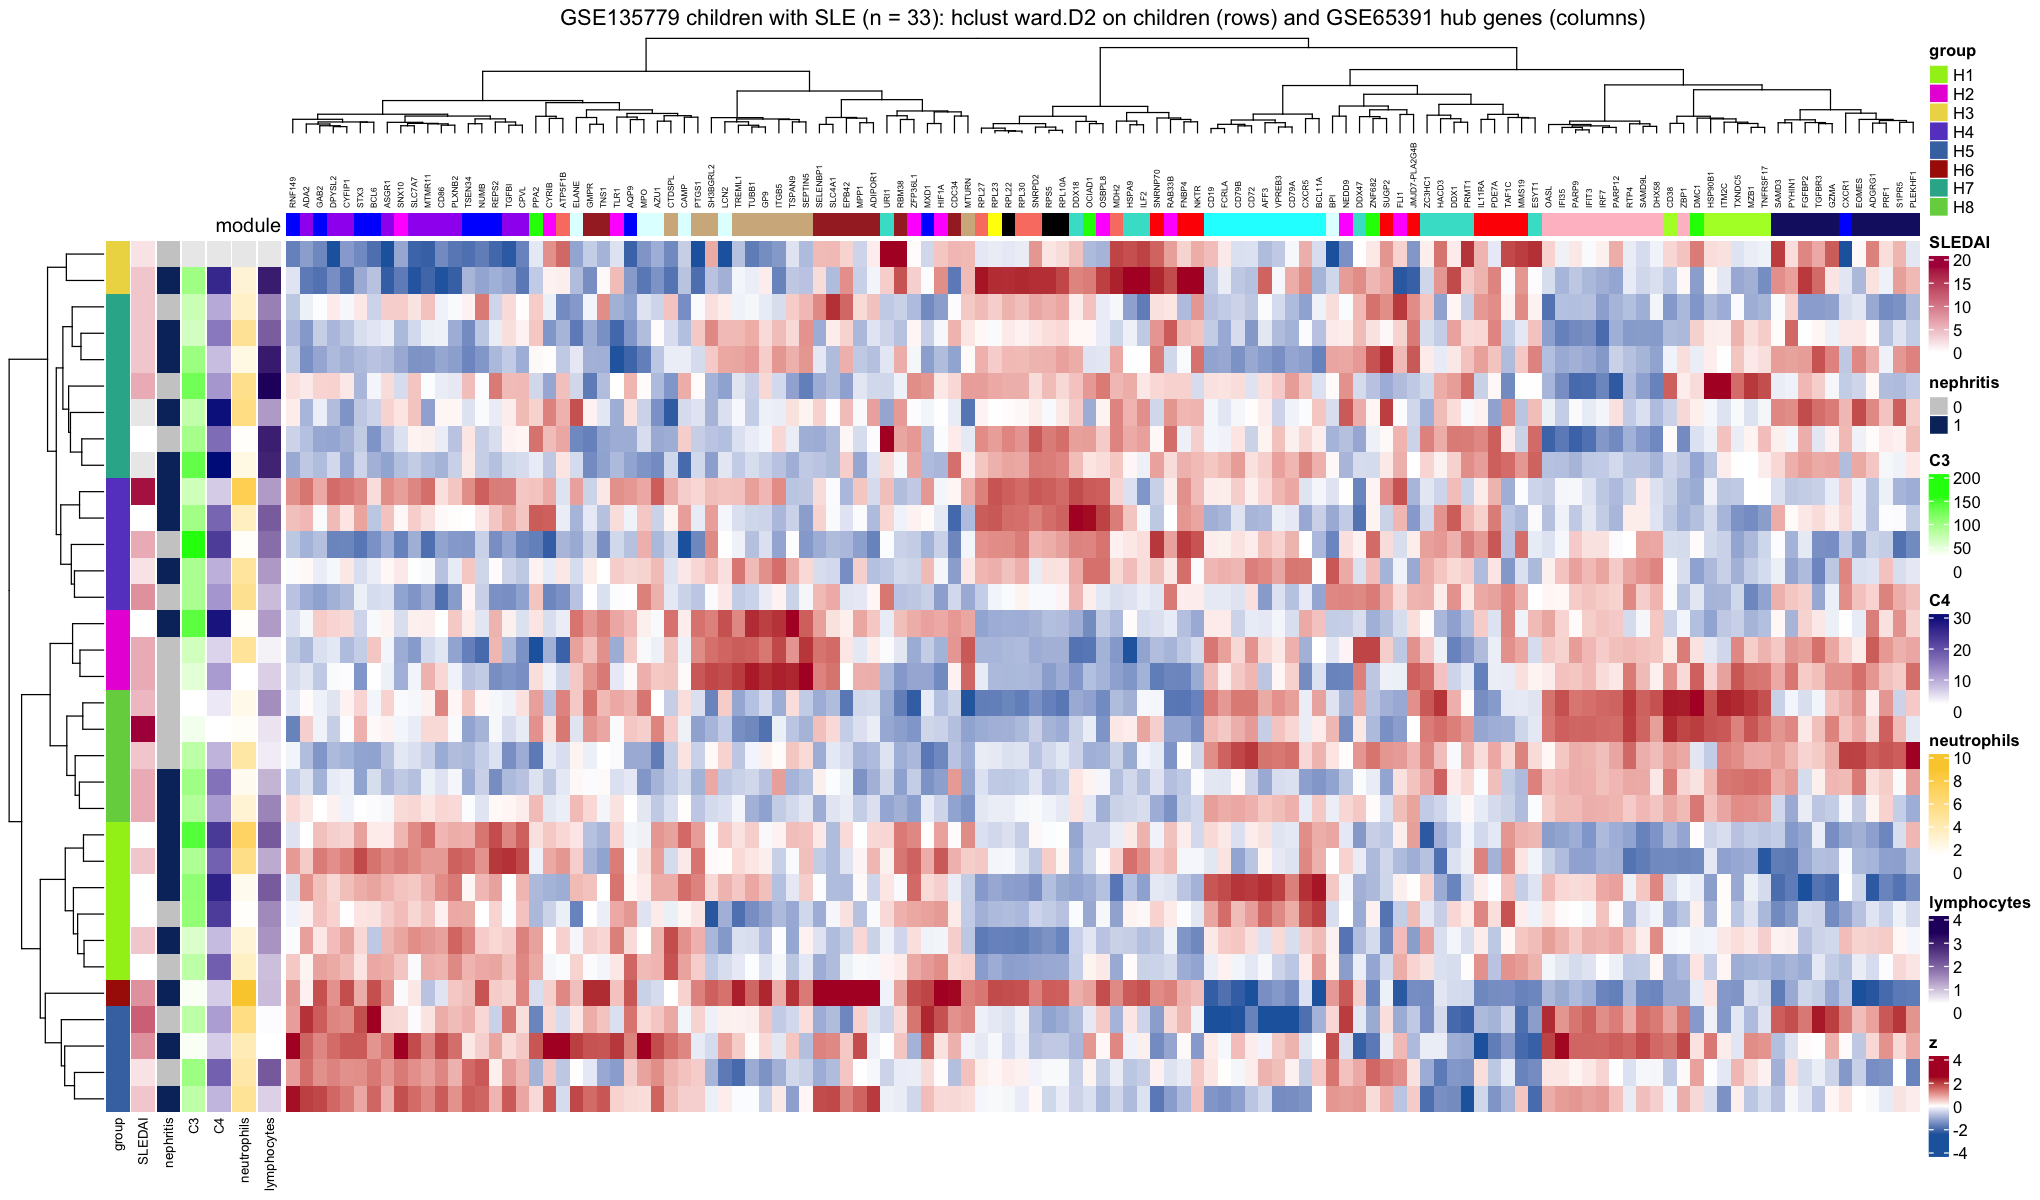

In [3]:
options(repr.plot.width = 17, repr.plot.height = 10)
Heatmap(t(pmin(pmax(Z, -2.5), 2.5)), name = "z", col = colorRamp2(c(-2.5, 0, 2.5), c("#2166AC", "white", "#B2182B")),
        cluster_rows = hc_children, cluster_columns = hc_genes,
        row_dend_side = "left", column_dend_side = "top",
        row_dend_width = unit(20, "mm"), column_dend_height = unit(20, "mm"),
        show_row_names = FALSE, column_names_side = "top", column_names_gp = gpar(fontsize = 5),
        top_annotation = HeatmapAnnotation(module = gene_module, col = list(module = setNames(unique(gene_module), unique(gene_module))),
                                           show_legend = FALSE, annotation_name_side = "left"),
        left_annotation = rowAnnotation(group = group, SLEDAI = traits$sledai, nephritis = factor(traits$nephritis_any),
                                          C3 = traits$c3, C4 = traits$c4, neutrophils = traits$neutrophil_count,
                                          lymphocytes = traits$lymphocyte_count, na_col = "grey92",
                                          col = list(nephritis = c("0" = "grey80", "1" = "#08306b")),
                                          annotation_name_gp = gpar(fontsize = 8)),
        column_title = "GSE135779 children with SLE (n = 33): hclust ward.D2 on children (rows) and GSE65391 hub genes (columns)")

In [4]:
group_tests(group)

,trait,test,n,p,q
,<chr>,<chr>,<int>,<dbl>,<dbl>
11,lymphocyte_count,Kruskal-Wallis,32,0.02709592,0.3768025
17,mdg,Kruskal-Wallis,33,0.06635341,0.3768025
9,wbc,Kruskal-Wallis,32,0.06649456,0.3768025
1,sledai,Kruskal-Wallis,31,0.13832481,0.4724978
2,stage,Kruskal-Wallis,31,0.13987603,0.4724978
8,c4,Kruskal-Wallis,32,0.16676395,0.4724978
5,age,Kruskal-Wallis,33,0.21791832,0.5292302
10,neutrophil_count,Kruskal-Wallis,32,0.28218514,0.5368936
14,mycophenolate,Fisher,33,0.28423781,0.5368936


**Result.** No trait reaches q < 0.05.